In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
import sklearn.metrics as skm
from tqdm import tqdm
from matplotlib.colors import LinearSegmentedColormap
import datetime as dt
import pickle

In [2]:
print(f'Last run date: {dt.datetime.today()}')

Last run date: 2024-03-25 17:26:06.994186


### Functions

In [3]:
# get metrics
def get_metrics(y_true, y_hat):
    dict_eval_metrics = {
        'Explained Variance': skm.explained_variance_score(y_true=y_true, y_pred=y_hat),
        'Mean Error': (y_true - y_hat).mean(),
        'Mean Absolute Error': skm.mean_absolute_error(y_true=y_true, y_pred=y_hat),
        'Mean Squared Error': skm.mean_squared_error(y_true=y_true, y_pred=y_hat),
        'Rooot Mean Squared Error': np.sqrt(skm.mean_squared_error(y_true=y_true, y_pred=y_hat)),
    }
    # make df
    df_tmp = pd.DataFrame({
        'Metric': list(dict_eval_metrics.keys()),
        'Score': list(dict_eval_metrics.values()),
    })
    # return
    return df_tmp

In [4]:
def get_less_equal_greater(genxii_minus_genxi):
    if genxii_minus_genxi > 0:
        return 'More'
    elif genxii_minus_genxi == 0:
        return 'Equal'
    elif genxii_minus_genxi < 0:
        return 'Less'
    else:
        return 'ERROR'

In [5]:
# group
def create_group(flt_ecnl):
    if flt_ecnl < 0:
        return '< 0'
    elif flt_ecnl < 0.01:
        return '0 - 0.01'
    elif flt_ecnl < 0.02:
        return '0.01 - 0.02'
    elif flt_ecnl < 0.03:
        return '0.02 - 0.03'
    elif flt_ecnl < 0.04:
        return '0.03 - 0.04'
    elif flt_ecnl < 0.05:
        return '0.04 - 0.05'
    elif flt_ecnl < 0.06:
        return '0.05 - 0.06'
    elif flt_ecnl < 0.07:
        return '0.06 - 0.07'
    elif flt_ecnl < 0.08:
        return '0.07 - 0.08'
    elif flt_ecnl < 0.09:
        return '0.08 - 0.09'
    elif flt_ecnl < 0.10:
        return '0.09 - 0.10'
    elif flt_ecnl < 0.11:
        return '0.10 - 0.11'
    elif flt_ecnl < 0.12:
        return '0.11 - 0.12'
    elif flt_ecnl < 0.13:
        return '0.12 - 0.13'
    elif flt_ecnl < 0.14:
        return '0.13 - 0.14'
    elif flt_ecnl < 0.15:
        return '0.14 - 0.15'
    elif flt_ecnl < 0.16:
        return '0.15 - 0.16'
    elif flt_ecnl < 0.17:
        return '0.16 - 0.17'
    elif flt_ecnl < 0.18:
        return '0.17 - 0.18'
    elif flt_ecnl < 0.19:
        return '0.18 - 0.19'
    elif flt_ecnl < 0.20:
        return '0.19 - 0.20'
    elif flt_ecnl < 0.21:
        return '0.20 - 0.21'
    elif flt_ecnl < 0.22:
        return '0.21 - 0.22'
    elif flt_ecnl < 0.23:
        return '0.22 - 0.23'
    elif flt_ecnl < 0.24:
        return '0.23 - 0.24'
    elif flt_ecnl < 0.25:
        return '0.24 - 0.25'
    elif flt_ecnl < 0.26:
        return '0.25 - 0.26'
    elif flt_ecnl < 0.27:
        return '0.26 - 0.27'
    elif flt_ecnl < 0.28:
        return '0.27 - 0.28'
    elif flt_ecnl < 0.29:
        return '0.28 - 0.29'
    elif flt_ecnl < 0.30:
        return '0.29 - 0.30'
    else:
        return '>= 0.31'

In [6]:
class SwapInSwapOut:
    def __init__(self):
        pass
    # create df
    def creat_swap_df(self, df, str_local_path):
        # get the groups
        df_tmp = df.groupby(by='group_genxi', as_index=False).agg({
        'ECNL_genxi': 'min',
        })
        df_tmp.sort_values(by='ECNL_genxi', ascending=True, inplace=True)
        list_str_group = list(df_tmp['group_genxi'])
        
        # loop through groups
        int_nrows_all = df.shape[0]
        list_dict_row = []
        for str_group in tqdm(list_str_group):
            # subset
            df_tmp = df[df['group_genxi'] == str_group].copy()
            # rows
            int_nrows_tmp = df_tmp.shape[0]

            # get gen xii freq
            ser_freq = df_tmp['group_genxii'].value_counts()
            # make dict
            dict_freq = dict(ser_freq)

            # dict_row
            dict_row = {
                'Group': str_group,
                'Count Gen XI': int_nrows_tmp,
            }
            # combine
            dict_row = {**dict_row, **dict_freq}
            # append
            list_dict_row.append(dict_row)
        # make df
        df_swap = pd.DataFrame(list_dict_row)
        
        # list of cols
        list_cols = ['Group','Count Gen XI'] + list_str_group
        list_cols = [col for col in list_cols if col in list(df_swap.columns)]
        # reorder
        df_swap = df_swap[list_cols].copy()
        # fill na
        df_swap.fillna(0, inplace=True)
        
        # logic for < 0
        if '< 0' not in list(df_swap.columns):
            df_swap.insert(2, '< 0', 0)
        else:
            pass

        # save
        df_swap.to_csv(str_local_path, index=False)
        
        # save to self
        self.df_swap = df_swap
    # create heatmap
    def create_heatmap(self, list_color, str_local_path):
        list_cols_ignore = [
            'Group',
            'Count Gen XI',
        ]
        list_cols = [col for col in self.df_swap.columns if col not in list_cols_ignore]
        # custom color mapping
        cmap = LinearSegmentedColormap.from_list('CustomColor', list_color)
        # make heatmap
        fig, ax = plt.subplots(figsize=(9,5))
        # title
        ax.set_title('Count of Values in Ranges for Gen XI and Gen XII')
        # plot
        sns.heatmap(
            self.df_swap[list_cols], 
            annot=False, 
            cmap=cmap, 
            ax=ax,
            yticklabels=list(self.df_swap['Group'])
        )
        # xlabel
        ax.set_xlabel('Gen XII ECNL Range')
        # ylabel
        ax.set_ylabel('Gen XI ECNL Range')
        # save
        plt.savefig(str_local_path, bbox_inches='tight')
        # show
        plt.show()

### Constants

In [7]:
# project
str_project = os.getcwd().split('/')[4].replace('_','-')
print(f'Project: {str_project}')
# task
str_task = os.getcwd().split('/')[5]
print(f'Task: {str_task}')
# subtask
str_subtask = os.getcwd().split('/')[6]
print(f'Subtask: {str_subtask}')
str_dirname_output = './output'
str_variant = 'noPTImodel7'

Project: 20231010-gen-xii
Task: 12_dark_scoring
Subtask: 04_swap_in_swap_out_plot


### Output dir

In [8]:
try:
    os.mkdir(str_dirname_output)
except:
    pass

### Variant dir

In [9]:
try:
    os.mkdir(f'{str_dirname_output}/{str_variant}')
except:
    pass

### Import data

In [10]:
str_filename = 'df_genxi_genxii_scores.gzip'
str_uri = f's3://{str_project}/{str_task}/{str_subtask}/{str_filename}'
df = pd.read_parquet(str_uri)
df

,bigAccountId,fltDebtorScore,strScoreCardVersion
0,7704337,0.123931,genxii_v2
1,7704337,0.181348,genxi_v2_3
2,7704336,0.043904,genxii_v2
3,7704336,0.089489,genxi_v2_3
4,7704336,0.043904,genxii_v2
...,...,...,...
74267,7656878,0.158159,genxi_v2_3
74268,7656878,0.126277,genxii_v2
74269,7656878,0.159840,genxi_v2_3
74270,7656878,0.126277,genxii_v2


### Gen XI Scores

In [11]:
df_genxi = df[df['strScoreCardVersion'] == 'genxi_v2_3'].copy()
df_genxi.drop_duplicates(subset=['bigAccountId'], keep='last', inplace=True)
dict_rename = {
    'fltDebtorScore': 'fltDebtorScore_genxi',
}
df_genxi.rename(columns=dict_rename, inplace=True)
list_cols = [
    'bigAccountId',
    'fltDebtorScore_genxi',
]
df_genxi['fltDebtorScore_genxi'] = df_genxi['fltDebtorScore_genxi'].clip(lower=0)
df_genxi = df_genxi[list_cols].copy()
df_genxi

,bigAccountId,fltDebtorScore_genxi
1,7704337,0.181348
5,7704336,0.089489
7,7704334,0.194914
11,7704333,0.134913
13,7704331,0.078971
...,...,...
74259,7656882,0.340572
74261,7656851,0.097306
74263,7654496,0.133895
74266,7656831,0.141652


### Get target ECNL factor

In [12]:
str_filename = 'flt_best_factor.pkl'
str_local_path = f'../../02_get_thresholds/output/{str_filename}'
flt_factor_target_ecnl = pickle.load(open(str_local_path, 'rb'))
flt_factor_target_ecnl = 1
print(f'Best factor: {flt_factor_target_ecnl:0.4f}')

Best factor: 1.0000


### Get Gen XII Scores

In [13]:
df_genxii = df[df['strScoreCardVersion'] == 'genxii_v2'].copy()
df_genxii.drop_duplicates(subset=['bigAccountId'], keep='last', inplace=True)
dict_rename = {
    'fltDebtorScore': 'fltDebtorScore_genxii',
}
df_genxii.rename(columns=dict_rename, inplace=True)
list_cols = [
    'bigAccountId',
    'fltDebtorScore_genxii',
]
df_genxii['fltDebtorScore_genxii'] = df_genxii['fltDebtorScore_genxii'] * flt_factor_target_ecnl
df_genxii['fltDebtorScore_genxii'] = df_genxii['fltDebtorScore_genxii'].clip(lower=0)
df_genxii = df_genxii[list_cols].copy()
df_genxii

,bigAccountId,fltDebtorScore_genxii
0,7704337,0.123931
4,7704336,0.043904
6,7704334,0.182442
10,7704333,0.072801
12,7704331,0.147814
...,...,...
74258,7656882,0.272202
74260,7656851,0.116894
74262,7654496,0.090431
74265,7656831,0.086832


### Join

In [14]:
df = pd.merge(
    left=df_genxi,
    right=df_genxii,
    on='bigAccountId',
    how='inner',
)
dict_rename = {
    'fltDebtorScore_genxi': 'ECNL_genxi',
    'fltDebtorScore_genxii': 'ECNL_genxii',
}
df.rename(columns=dict_rename, inplace=True)
df

,bigAccountId,ECNL_genxi,ECNL_genxii
0,7704337,0.181348,0.123931
1,7704336,0.089489,0.043904
2,7704334,0.194914,0.182442
3,7704333,0.134913,0.072801
4,7704331,0.078971,0.147814
...,...,...,...
18239,7656882,0.340572,0.272202
18240,7656851,0.097306,0.116894
18241,7654496,0.133895,0.090431
18242,7656831,0.141652,0.086832


### Min and max dates

In [15]:
# dtm_min = df['applicationdate'].min()
# dtm_max = df['applicationdate'].max()
# print(f'Min date: {dtm_min.date()}; Max date: {dtm_max.date()}')

### Distributions

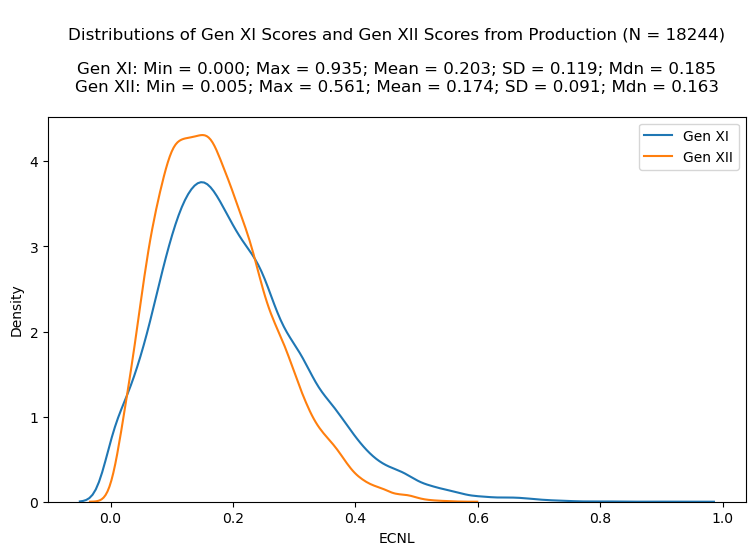

In [16]:
# gen xi
list_x = list(df['ECNL_genxi'])
flt_min_x = np.min(list_x)
flt_max_x = np.max(list_x)
flt_mean_x = np.mean(list_x)
flt_std_x = np.std(list_x)
flt_mdn_x = np.median(list_x)
# gen xii
list_y = list(df['ECNL_genxii'])
flt_min_y = np.min(list_y)
flt_max_y = np.max(list_y)
flt_mean_y = np.mean(list_y)
flt_std_y = np.std(list_y)
flt_mdn_y = np.median(list_y)

# plot
fig, ax = plt.subplots(figsize=(9,5))
str_title = f"""
Distributions of Gen XI Scores and Gen XII Scores from Production (N = {df.shape[0]})

Gen XI: Min = {flt_min_x:0.3f}; Max = {flt_max_x:0.3f}; Mean = {flt_mean_x:0.3f}; SD = {flt_std_x:0.3f}; Mdn = {flt_mdn_x:0.3f}
Gen XII: Min = {flt_min_y:0.3f}; Max = {flt_max_y:0.3f}; Mean = {flt_mean_y:0.3f}; SD = {flt_std_y:0.3f}; Mdn = {flt_mdn_y:0.3f}
"""
ax.set_title(str_title)
ax.set_xlabel('ECNL')
# plot lines
sns.kdeplot(list_x, label='Gen XI')
sns.kdeplot(list_y, label='Gen XII')
# legend
plt.legend()

# save
str_filename = 'plt_kde_prod.png'
str_local_path = f'{str_dirname_output}/{str_variant}/{str_filename}'
plt.savefig(str_local_path, bbox_inches='tight')

# show
plt.show()

### Scatterplot (no rank)

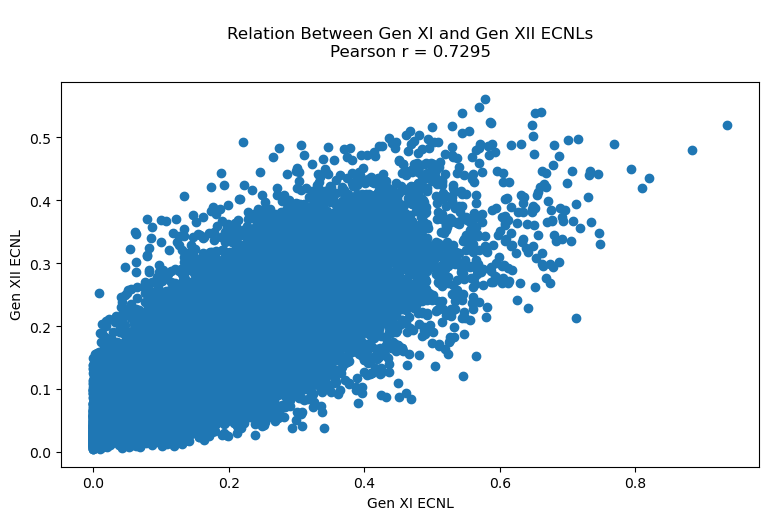

In [17]:
ser_x = df['ECNL_genxi']
ser_y = df['ECNL_genxii']
flt_r = pearsonr(ser_x, ser_y)[0]
# ax
fig, ax = plt.subplots(figsize=(9,5))
str_title = f"""
Relation Between Gen XI and Gen XII ECNLs
Pearson r = {flt_r:0.4f}
"""
ax.set_title(str_title)
ax.set_xlabel('Gen XI ECNL')
ax.set_ylabel('Gen XII ECNL')
# plot
ax.scatter(ser_x, ser_y)

# save
str_filename = 'plt_scatter_prod.png'
str_local_path = f'{str_dirname_output}/{str_variant}/{str_filename}'
plt.savefig(str_local_path, bbox_inches='tight')

# show
plt.show()

### Scatterplot (with rank)

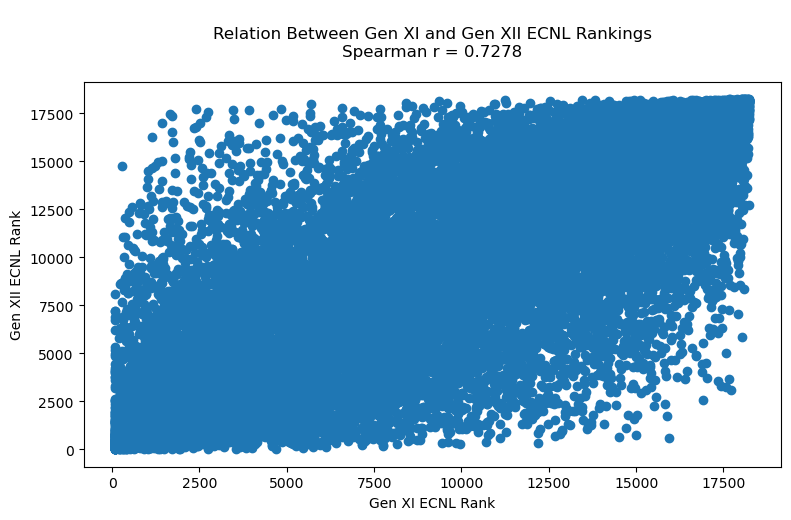

In [18]:
df['rank_genxi'] = df['ECNL_genxi'].rank()
df['rank_genxii'] = df['ECNL_genxii'].rank()

ser_x = df['rank_genxi']
ser_y = df['rank_genxii']
flt_r = spearmanr(ser_x, ser_y)[0]
# ax
fig, ax = plt.subplots(figsize=(9,5))
str_title = f"""
Relation Between Gen XI and Gen XII ECNL Rankings
Spearman r = {flt_r:0.4f}
"""
ax.set_title(str_title)
ax.set_xlabel('Gen XI ECNL Rank')
ax.set_ylabel('Gen XII ECNL Rank')
# plot
ax.scatter(ser_x, ser_y)

# save
str_filename = 'plt_scatter_rank_prod.png'
str_local_path = f'{str_dirname_output}/{str_variant}/{str_filename}'
plt.savefig(str_local_path, bbox_inches='tight')

# show
plt.show()

### Regression metrics

In [19]:
df_tmp = get_metrics(
    y_true=df['ECNL_genxi'], 
    y_hat=df['ECNL_genxii'],
)
df_tmp

,Metric,Score
0,Explained Variance,0.530991
1,Mean Error,0.029272
2,Mean Absolute Error,0.064372
3,Mean Squared Error,0.007488
4,Rooot Mean Squared Error,0.086532


### Plot the scores together

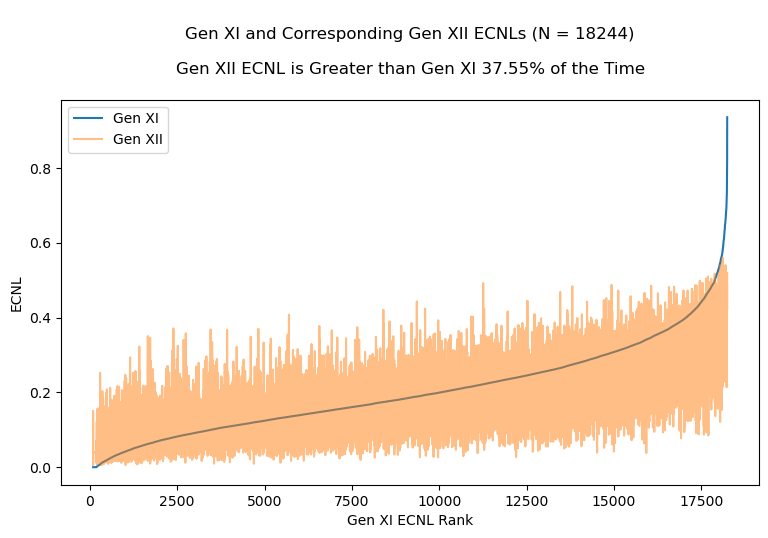

In [20]:
# analysis
df['genxii_minus_genxi'] = df['ECNL_genxii'] - df['ECNL_genxi']
df['code'] = df['genxii_minus_genxi'].apply(get_less_equal_greater)
dict_tmp = dict(df['code'].value_counts(normalize=True))
flt_more = dict_tmp['More']

# sort
df.sort_values(by='ECNL_genxi', ascending=True, inplace=True)
# ax
fig, ax = plt.subplots(figsize=(9,5))
# title
str_title = f"""
Gen XI and Corresponding Gen XII ECNLs (N = {df.shape[0]})

Gen XII ECNL is Greater than Gen XI {flt_more*100:0.4}% of the Time
"""
ax.set_title(str_title)
ax.set_xlabel('Gen XI ECNL Rank')
ax.set_ylabel('ECNL')
# line gen xi
ax.plot(df['rank_genxi'], df['ECNL_genxi'], label='Gen XI')
# line gen xii
ax.plot(df['rank_genxi'], df['ECNL_genxii'], alpha=0.5, label='Gen XII')
# legend
plt.legend()

# save
str_filename = 'plt_corresponding_scores_prod.png'
str_local_path = f'{str_dirname_output}/{str_variant}/{str_filename}'
plt.savefig(str_local_path, bbox_inches='tight')

# show
plt.show()

### Put ECNLs into bins

In [21]:
# make groups
df['group_genxi'] = df['ECNL_genxi'].apply(create_group)
df['group_genxii'] = df['ECNL_genxii'].apply(create_group)
# show
df

,bigAccountId,ECNL_genxi,ECNL_genxii,rank_genxi,rank_genxii,genxii_minus_genxi,code,group_genxi,group_genxii
9666,7669521,0.000000,0.020541,92.0,176.0,0.020541,More,0 - 0.01,0.02 - 0.03
1475,7682103,0.000000,0.062115,92.0,1668.0,0.062115,More,0 - 0.01,0.06 - 0.07
14896,7661607,0.000000,0.050396,92.0,1047.0,0.050396,More,0 - 0.01,0.05 - 0.06
11005,7667468,0.000000,0.057646,92.0,1408.0,0.057646,More,0 - 0.01,0.05 - 0.06
1908,7681448,0.000000,0.048614,92.0,975.0,0.048614,More,0 - 0.01,0.04 - 0.05
...,...,...,...,...,...,...,...,...,...
6944,7673669,0.792761,0.449622,18240.0,18152.0,-0.343139,Less,>= 0.31,>= 0.31
2081,7681197,0.809245,0.419038,18241.0,18044.0,-0.390208,Less,>= 0.31,>= 0.31
11252,7667076,0.819513,0.435786,18242.0,18103.0,-0.383727,Less,>= 0.31,>= 0.31
15530,7660696,0.884133,0.480241,18243.0,18197.0,-0.403891,Less,>= 0.31,>= 0.31


### Binned frequencies

In [22]:
# gen xi
ser_freq = df['group_genxi'].value_counts(normalize=True)
df_freq = ser_freq.reset_index()
df_freq.columns = ['Group','Proportion Gen XI']

# gen xii
ser_freq = df['group_genxii'].value_counts(normalize=True)
df_freq_tmp = ser_freq.reset_index()
df_freq_tmp.columns = ['Group','Proportion Gen XII']

# join
df_freq = pd.merge(
    left=df_freq,
    right=df_freq_tmp,
    on='Group',
    how='left'
)

# get diff
df_freq['Difference'] = df_freq['Proportion Gen XII'] - df_freq['Proportion Gen XI']

# get absolute value
df_freq['Absolute Difference'] = df_freq['Difference'].apply(abs)

# sort
df_freq.sort_values(by='Absolute Difference', ascending=True, inplace=True)

# show
df_freq

,Group,Proportion Gen XI,Proportion Gen XII,Difference,Absolute Difference
29,0.02 - 0.03,0.011237,0.011456,0.000219,0.000219
20,0.26 - 0.27,0.021815,0.021541,-0.000274,0.000274
23,0.28 - 0.29,0.019733,0.019294,-0.000439,0.000439
14,0.23 - 0.24,0.029489,0.028941,-0.000548,0.000548
28,0.03 - 0.04,0.014251,0.016279,0.002028,0.002028
15,0.22 - 0.23,0.029434,0.031572,0.002138,0.002138
21,0.27 - 0.28,0.021541,0.019184,-0.002357,0.002357
17,0.24 - 0.25,0.027571,0.025159,-0.002412,0.002412
24,0.29 - 0.30,0.018636,0.016115,-0.002521,0.002521
8,0.18 - 0.19,0.034696,0.037273,0.002576,0.002576


### Swap in and swap out plot

100%|██████████| 31/31 [00:00<00:00, 393.17it/s]


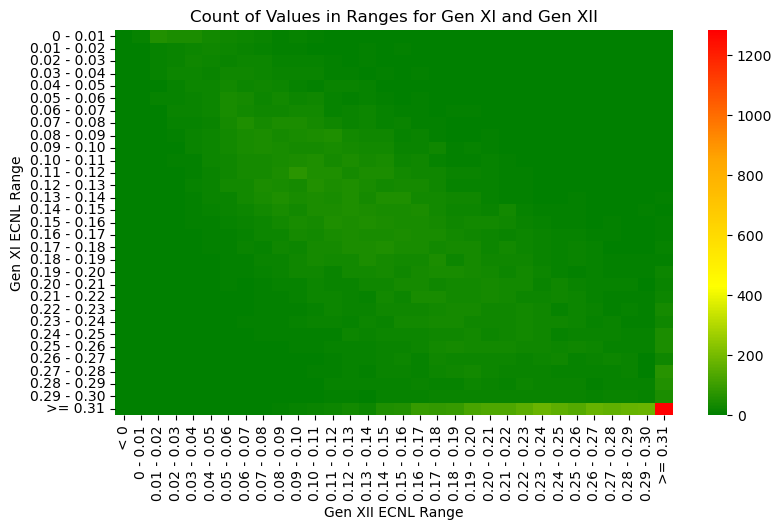

In [23]:
# init
cls_swap_in_swap_out = SwapInSwapOut()
# create df
str_filename = 'df_swap.csv'
str_local_path = f'{str_dirname_output}/{str_variant}/{str_filename}'
cls_swap_in_swap_out.creat_swap_df(
    df=df, 
    str_local_path=str_local_path,
)
# create plot
str_filename = 'plt_swap_heatmap.png'
str_local_path = f'{str_dirname_output}/{str_variant}/{str_filename}'
cls_swap_in_swap_out.create_heatmap(
    list_color=['green','yellow','orange','red'], 
    str_local_path=str_local_path,
)